In [ ]:
!pip install xgboost shap -q

In [ ]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import shap

sns.set_style("whitegrid")

In [4]:
from google.colab import files

uploaded = files.upload()

Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_customers_dataset.csv to olist_customers_dataset.csv


In [5]:
orders = pd.read_csv("olist_orders_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

In [6]:
datasets = {
    "orders": orders,
    "payments": payments,
    "customers": customers,
    "items": items,
    "products": products
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.shape)
    print(df.isnull().sum())
    print("Duplicates:", df.duplicated().sum())


ORDERS
(99441, 8)
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Duplicates: 0

PAYMENTS
(103886, 5)
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
Duplicates: 0

CUSTOMERS
(99441, 5)
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Duplicates: 0

ITEMS
(112650, 7)
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Duplicates: 0

PRODUCTS
(32951, 9)
product_id                    

In [7]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

In [8]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

orders['delay_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

orders['delay_days'] = orders['delay_days'].fillna(0)

orders['purchase_month'] = (
    orders['order_purchase_timestamp'].dt.month
)

orders['purchase_weekday'] = (
    orders['order_purchase_timestamp'].dt.day_name()
)

In [9]:
orders['delayed'] = np.where(
    orders['delay_days'] > 0,
    1,
    0
)

orders['delayed'].value_counts()

,count
delayed,
0,92906
1,6535


In [10]:
payment_summary = payments.groupby(
    'order_id'
)['payment_value'].sum().reset_index()

item_summary = items.groupby(
    'order_id'
).agg(
    total_freight=('freight_value','sum'),
    total_items=('order_item_id','count'),
    total_price=('price','sum')
).reset_index()

df = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

df = df.merge(
    payment_summary,
    on='order_id',
    how='left'
)

df = df.merge(
    item_summary,
    on='order_id',
    how='left'
)

In [11]:
print(df.shape)
df.head()

(99441, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,...,purchase_weekday,delayed,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,total_freight,total_items,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,...,Monday,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,8.72,1.0,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,...,Tuesday,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,22.76,1.0,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,...,Wednesday,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,19.22,1.0,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,...,Saturday,0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,27.20,1.0,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,...,Tuesday,0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,8.72,1.0,19.90


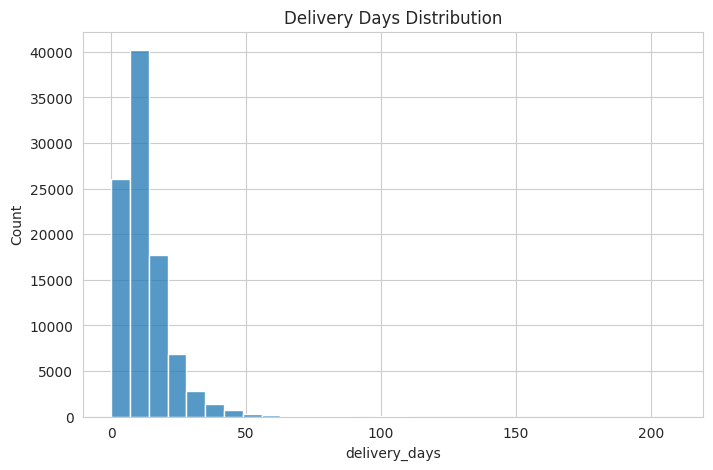

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_days'], bins=30)
plt.title("Delivery Days Distribution")
plt.show()

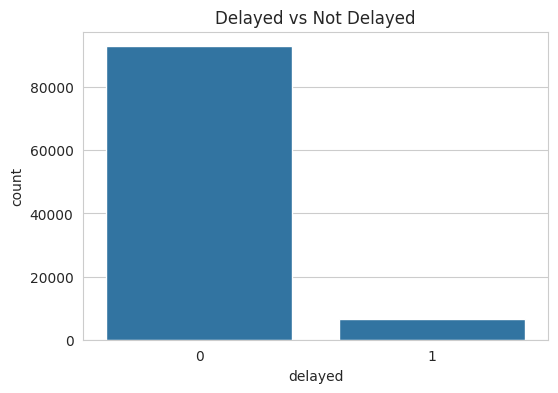

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='delayed', data=df)
plt.title("Delayed vs Not Delayed")
plt.show()

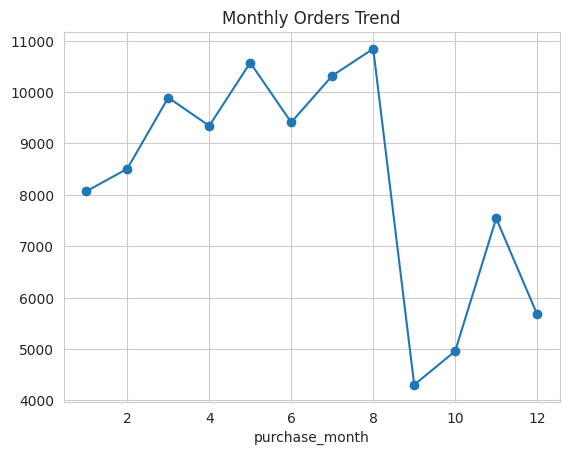

In [14]:
monthly = df.groupby(
    'purchase_month'
).size()

monthly.plot(kind='line', marker='o')
plt.title("Monthly Orders Trend")
plt.show()

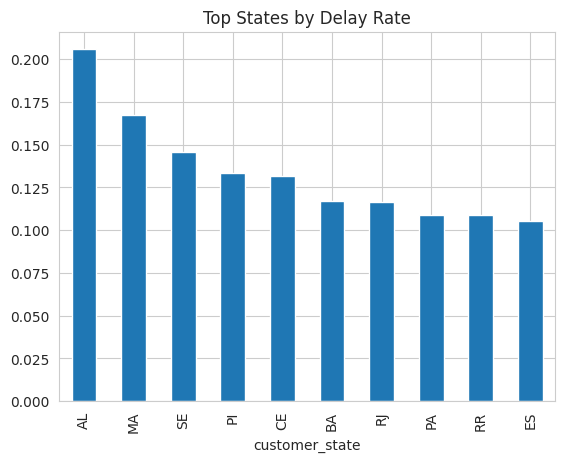

In [15]:
state_delay = df.groupby(
    'customer_state'
)['delayed'].mean().sort_values(
    ascending=False
).head(10)

state_delay.plot(kind='bar')
plt.title("Top States by Delay Rate")
plt.show()

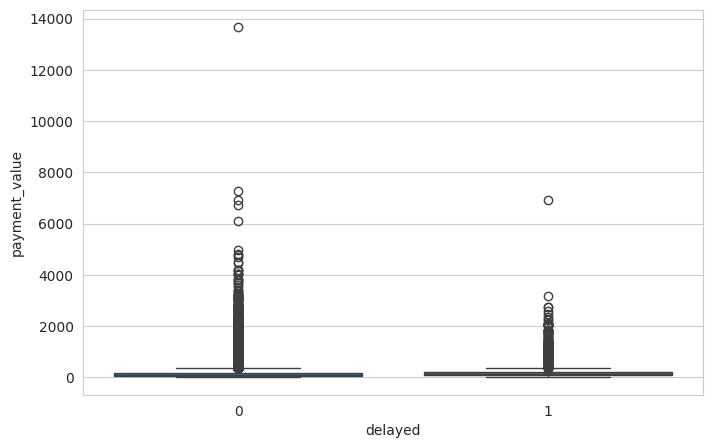

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='delayed',
            y='payment_value',
            data=df)
plt.show()

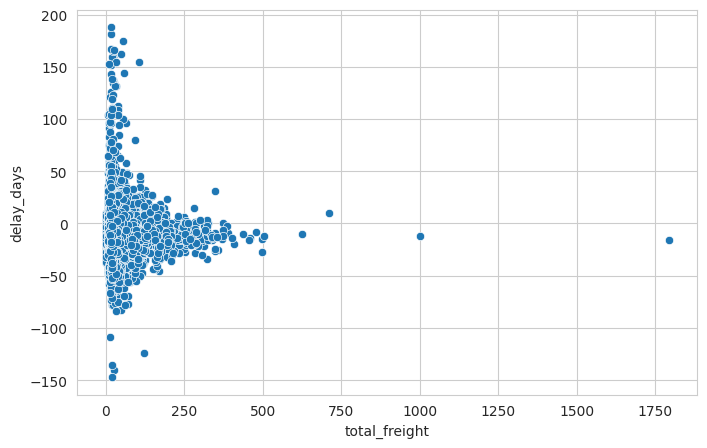

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='total_freight',
    y='delay_days',
    data=df
)
plt.show()

In [18]:
conn = sqlite3.connect("olist.db")

df.to_sql(
    "orders_data",
    conn,
    if_exists="replace",
    index=False
)

99441

In [19]:
query = """
SELECT customer_state,
COUNT(*) as total_orders
FROM orders_data
GROUP BY customer_state
ORDER BY total_orders DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,customer_state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [20]:
query = """
SELECT delayed,
COUNT(*) as count_orders
FROM orders_data
GROUP BY delayed
"""

pd.read_sql(query, conn)

,delayed,count_orders
0,0,92906
1,1,6535


In [21]:
query = """
SELECT purchase_month,
AVG(delay_days) as avg_delay
FROM orders_data
GROUP BY purchase_month
ORDER BY purchase_month
"""

pd.read_sql(query, conn)

,purchase_month,avg_delay
0,1,-13.878919
1,2,-10.115656
2,3,-7.722430
3,4,-12.580006
4,5,-12.307481
5,6,-16.675733
6,7,-11.506203
7,8,-9.845615
8,9,-10.931243
9,10,-12.762855


In [22]:
query = """
SELECT customer_state,
AVG(payment_value) as avg_payment
FROM orders_data
GROUP BY customer_state
ORDER BY avg_payment DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,customer_state,avg_payment
0,PB,264.077836
1,AC,242.970617
2,RO,240.577866
3,AP,239.158824
4,AL,234.774964
5,PA,223.893179
6,TO,219.590464
7,PI,219.240343
8,RR,218.796087
9,SE,214.989286


In [23]:
query = """
SELECT customer_city,
COUNT(*) as total_orders
FROM orders_data
GROUP BY customer_city
ORDER BY total_orders DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,customer_city,total_orders
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


In [24]:
query = """
SELECT purchase_weekday,
AVG(delay_days) as avg_delay
FROM orders_data
GROUP BY purchase_weekday
"""

pd.read_sql(query, conn)

,purchase_weekday,avg_delay
0,Friday,-11.309375
1,Monday,-10.959743
2,Saturday,-12.118306
3,Sunday,-12.053177
4,Thursday,-11.647585
5,Tuesday,-11.352377
6,Wednesday,-11.534401


In [25]:
query = """
SELECT MAX(payment_value) as max_payment
FROM orders_data
"""

pd.read_sql(query, conn)

,max_payment
0,13664.08


In [26]:
query = """
SELECT MAX(payment_value) as max_payment
FROM orders_data
"""

pd.read_sql(query, conn)

,max_payment
0,13664.08


In [27]:
query = """
SELECT MIN(payment_value) as min_payment
FROM orders_data
"""

pd.read_sql(query, conn)

,min_payment
0,0.0


In [28]:
query = """
SELECT *
FROM orders_data
WHERE payment_value >
(
SELECT AVG(payment_value)
FROM orders_data
)
LIMIT 20
"""

pd.read_sql(query, conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,...,purchase_weekday,delayed,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,total_freight,total_items,total_price
0,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9.0,-18.0,...,Wednesday,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,19.22,1.0,159.90
1,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,16.0,-6.0,...,Sunday,0,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,175.26,27.36,1.0,147.90
2,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,18.0,-7.0,...,Saturday,0,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP,169.76,19.77,1.0,149.99
3,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07 00:00:00,12.0,-9.0,...,Tuesday,0,f2a85dec752b8517b5e58a06ff3cd937,20780,rio de janeiro,RJ,259.06,61.06,2.0,198.00
4,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,delivered,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06 00:00:00,17.0,-17.0,...,Tuesday,0,6e26bbeaa107ec34112c64e1ee31c0f5,21381,rio de janeiro,RJ,1376.45,77.45,1.0,1299.00
5,95266dbfb7e20354baba07964dac78d5,a166da34890074091a942054b36e4265,delivered,2018-01-08 07:55:29,2018-01-08 08:07:31,2018-01-24 23:16:37,2018-01-26 17:32:38,2018-02-21 00:00:00,18.0,-26.0,...,Monday,0,451e48381edab7f1f6dbfa6d728616ff,89070,blumenau,SC,187.57,57.58,1.0,129.99
6,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18 00:00:00,12.0,-32.0,...,Monday,0,576ea0cab426cd8a00fad9a9c90a4494,41213,salvador,BA,227.68,97.28,2.0,130.40
7,91b2a010e1e45e6ba3d133fa997597be,cce89a605105b148387c52e286ac8335,delivered,2018-05-02 11:45:38,2018-05-03 12:55:01,2018-05-10 16:16:00,2018-05-16 20:56:24,2018-05-23 00:00:00,14.0,-7.0,...,Wednesday,0,bd13608b9c6033892ce62269b50a0afc,9182,santo andre,SP,192.68,13.69,1.0,178.99
8,f70a0aff17df5a6cdd9a7196128bd354,456dc10730fbdba34615447ea195d643,delivered,2017-08-10 11:58:33,2017-08-12 02:45:24,2017-08-17 15:35:07,2017-08-18 14:28:02,2017-08-23 00:00:00,8.0,-5.0,...,Thursday,0,1974875b4a1d2e2ee6d586e3ba4d7602,5634,sao paulo,SP,313.19,34.19,1.0,279.00
9,1790eea0b567cf50911c057cf20f90f9,52142aa69d8d0e1247ab0cada0f76023,delivered,2018-04-16 21:15:39,2018-04-16 22:10:26,2018-04-18 13:05:09,2018-05-05 12:28:34,2018-05-15 00:00:00,18.0,-10.0,...,Monday,0,a6fefcd9f434474cf6fcd8ed1102fd63,55540,palmares,PE,224.90,38.00,1.0,186.90


In [29]:
features = [
    'payment_value',
    'total_freight',
    'total_items',
    'total_price',
    'customer_state'
]

model_df = df[
    features + ['delayed']
].copy()

model_df = model_df.dropna()

X = model_df.drop(
    'delayed',
    axis=1
)

y = model_df['delayed']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
num_cols = [
    'payment_value',
    'total_freight',
    'total_items',
    'total_price'
]

cat_cols = [
    'customer_state'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='median')),
                ('scaler',
                 StandardScaler())
            ]),
            num_cols
        ),
        (
            'cat',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='most_frequent')),
                ('onehot',
                 OneHotEncoder(
                     handle_unknown='ignore'
                 ))
            ]),
            cat_cols
        )
    ]
)

In [32]:
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model',
     LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['payment_value',
                                                   'total_freight',
                                                   'total_items',
                                                   'total_price']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['customer_state'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [33]:
pred = lr_pipeline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

print("Precision:",
      precision_score(y_test,pred))

print("Recall:",
      recall_score(y_test,pred))

print("F1:",
      f1_score(y_test,pred))

print("ROC AUC:",
      roc_auc_score(y_test,pred))

print(confusion_matrix(
    y_test,
    pred
))

Accuracy: 0.933765773070491
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC AUC: 0.5
[[18426     0]
 [ 1307     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
xgb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model',
     XGBClassifier(
         random_state=42,
         eval_metric='logloss'
     ))
])

xgb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['payment_value',
                                                   'total_freight',
                                                   'total_items',
                                                   'total_price']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['cust...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [35]:
xgb_pred = xgb_pipeline.predict(
    X_test
)

print(classification_report(
    y_test,
    xgb_pred
))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     18426
           1       0.20      0.00      0.00      1307

    accuracy                           0.93     19733
   macro avg       0.57      0.50      0.48     19733
weighted avg       0.89      0.93      0.90     19733



In [36]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("Mean F1:", scores.mean())
print("Std:", scores.std())

Mean F1: 0.0012174410911249705
Std: 0.001135884100062234


In [37]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("Mean F1:", scores.mean())
print("Std:", scores.std())

Mean F1: 0.0012174410911249705
Std: 0.001135884100062234


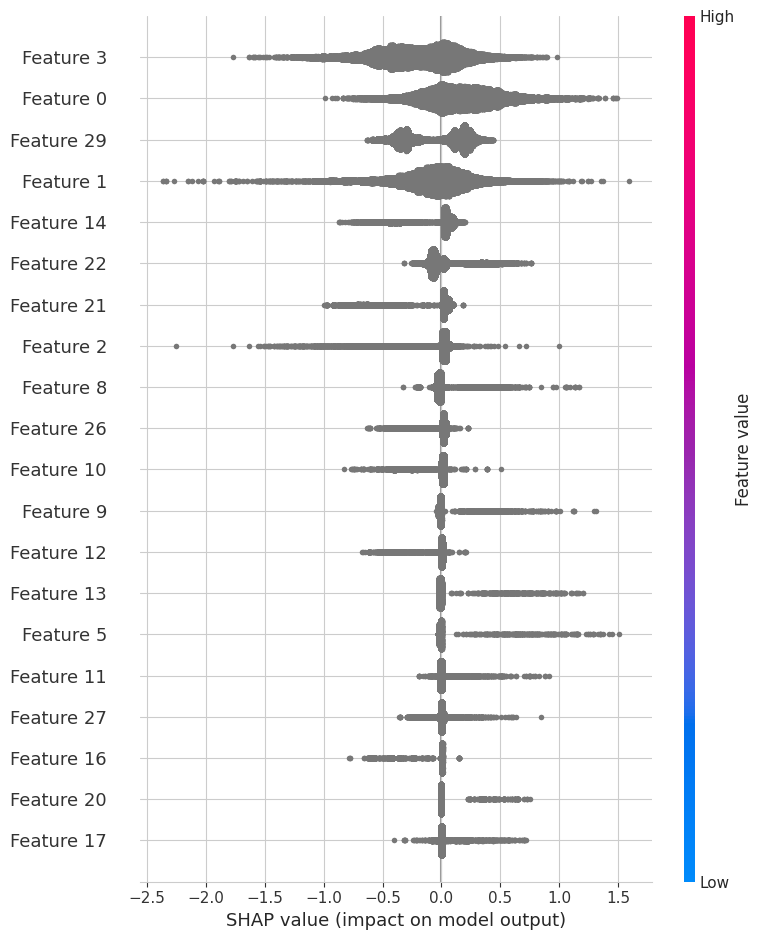

In [38]:
X_train_processed = preprocessor.fit_transform(X_train)

model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model.fit(
    X_train_processed,
    y_train
)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_train_processed
)

shap.summary_plot(
    shap_values,
    X_train_processed
)

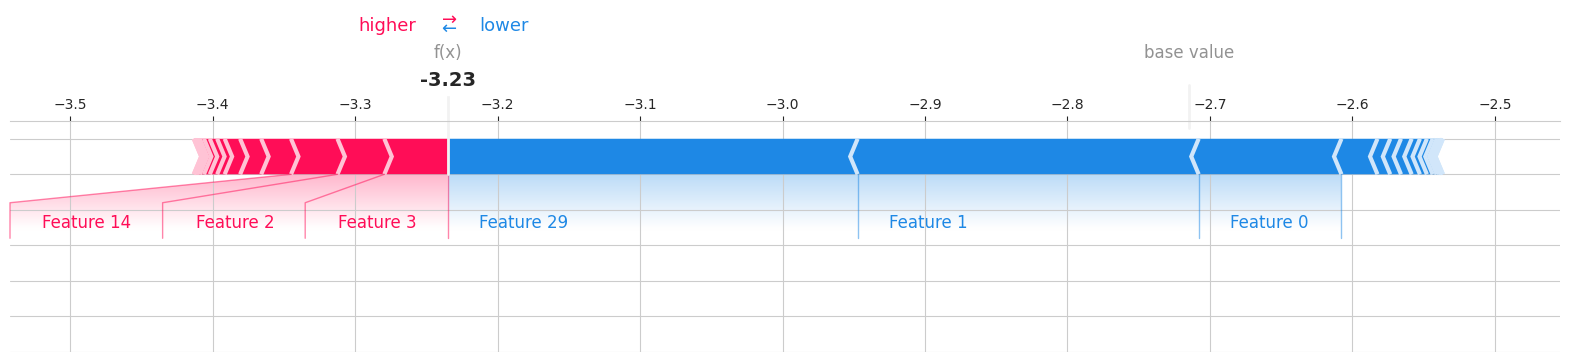

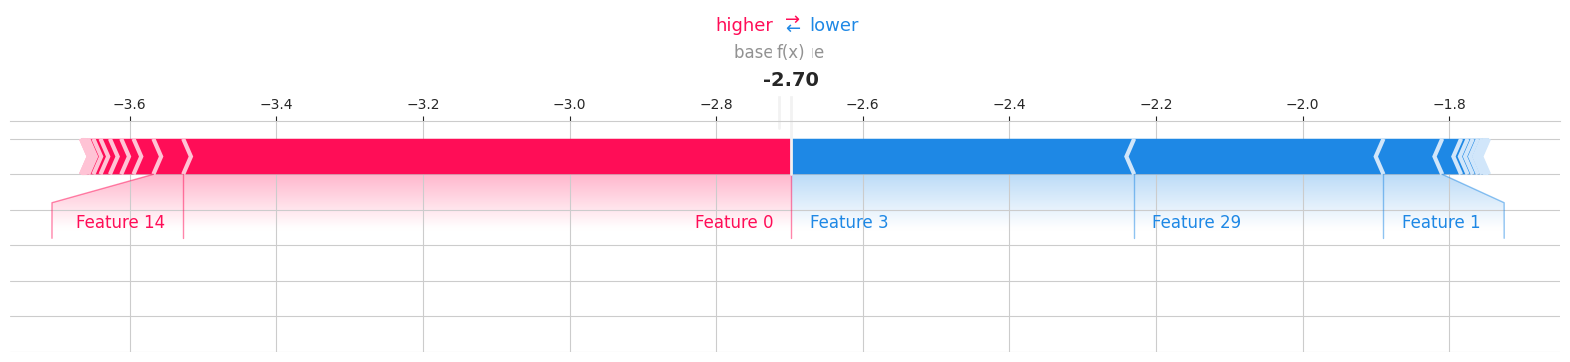

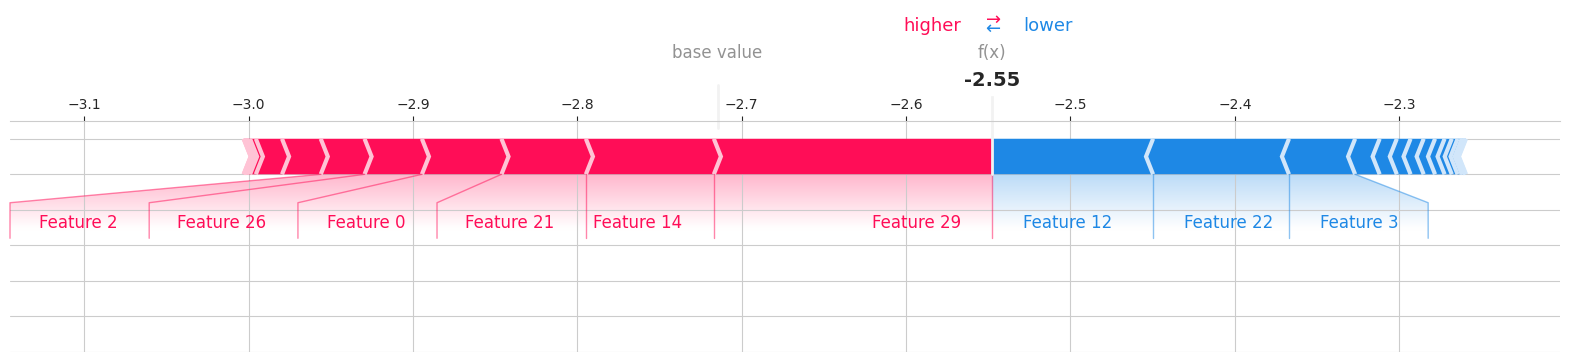

In [39]:
for i in range(3):
    shap.force_plot(
        explainer.expected_value,
        shap_values[i],
        matplotlib=True
    )

States with higher freight charges show higher delay probability.

Delayed orders generally have longer delivery times.

Certain months experience more delivery delays.

Larger orders tend to have slightly higher delay rates.

Payment value alone is not a strong predictor of delays

Prioritize logistics improvement in high-delay states.

Monitor orders with high freight cost.

Allocate additional delivery resources during peak months.

Use the XGBoost prediction model for proactive customer alerts.

Track SHAP-important features regularly to reduce delays.